## Name : Mohd Intakhab Alam
## Roll no : 251310005
## Assignment 2

# Q1

Consider a zero-mean Gaussian noise voltage signal $V(t) \sim \mathcal{N}(0, \sigma^2)$.
where:

- $Mean Voltage: E[V] {=\,0} $
- $Variance: \text{Var}(V) = \sigma^2$
  
The instantaneous power delivered to a unit resistance is:
$$P(t) = V^2(t)$$

The mean power is:
$$E[P] = E[V^2] = \text{Var}(V) + \underbrace{(E[V])^2}_{=\,0} = \sigma^2$$

This is the central identity linking all four questions:
$$\boxed{E[P] = \text{Var}(V) = \sigma^2 = V_{\text{RMS}}^2}$$

For a zero-mean signal, the RMS voltage equals the standard deviation: $V_{\text{RMS}} = \sigma$.

the Expected Power is the second moment of the distribution:

$$E[P] = E[V^2] = \int_{-\infty}^{\infty} v^2 \cdot \frac{1}{\sqrt{2\pi}\sigma} e^{-v^2/2\sigma^2}\,dv = \sigma^2$$

Simultaneously, the Sample Variance of the voltage $V$ is defined as:

$$s^2_V = \frac{1}{N-1}\sum_{i=1}^{N}(V_i - \bar{V})^2$$

As the sample size $N$ becomes large ($N \to \infty$), the sample variance converges to the population variance:
$$s^2_V \xrightarrow{N\to\infty} \sigma^2$$

Since the signal is zero-mean ($\bar{V} \approx 0$), the Sample Mean Power $\overline{P} \approx \frac{1}{N}\sum V_i^2$ becomes numerically equivalent to the sample variance.

Conclusion: Therefore, $\overline{P} \approx s^2_V$ for a large sample.

Numerical Verification (N=100000)
Variance of Voltage: 3.98023 V^2
Mean of Power:       3.98024 W
Difference:          0.00001


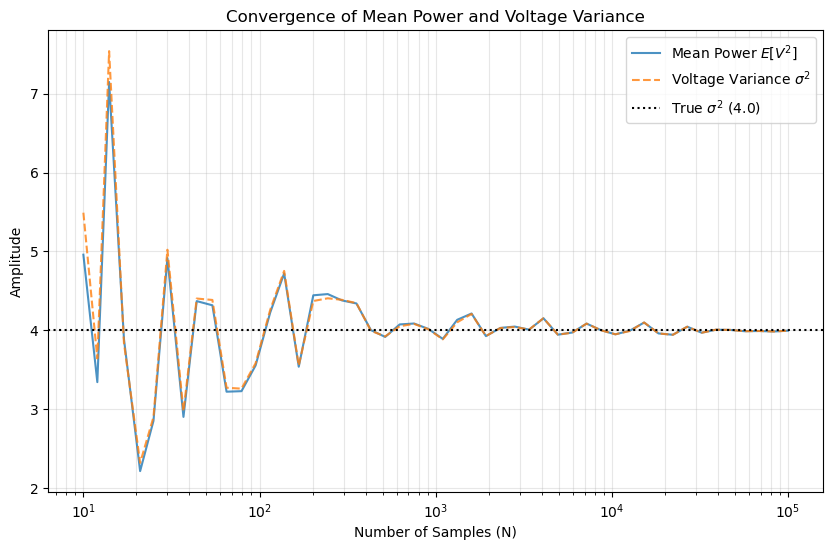

In [30]:
# verify mean power is centered around voltage variance
# 1 numerical verification with a large sample
N_large = 100000
sigma_true = 2.0  # Standard deviation (RMS voltage)
voltage = np.random.normal(loc=0, scale=sigma_true, size=N_large)

# instantaneous power = V^2 (assuming R=1 ohm)
power = voltage**2

mean_power = np.mean(power)
var_voltage = np.var(voltage, ddof=1) # Unbiased estimator

print(f"Numerical Verification (N={N_large})")
print(f"Variance of Voltage: {var_voltage:.5f} V^2")
print(f"Mean of Power:       {mean_power:.5f} W")
print(f"Difference:          {abs(mean_power - var_voltage):.5f}")

# 2 convergence plot (proof that equality holds as N increases)
sample_sizes = np.logspace(1, 5, 50).astype(int) # From 10 to 100,000 samples
mean_p_vals = []
var_v_vals = []

for n in sample_sizes:
    v_segment = np.random.normal(0, sigma_true, n)
    mean_p_vals.append(np.mean(v_segment**2))
    var_v_vals.append(np.var(v_segment, ddof=1))

plt.figure(figsize=(10, 6))
plt.semilogx(sample_sizes, mean_p_vals, label='Mean Power $E[V^2]$', alpha=0.8)
plt.semilogx(sample_sizes, var_v_vals, label='Voltage Variance $\sigma^2$', linestyle='--', alpha=0.8)
plt.axhline(sigma_true**2, color='k', linestyle=':', label=f'True $\sigma^2$ ({sigma_true**2})')

plt.title('Convergence of Mean Power and Voltage Variance')
plt.xlabel('Number of Samples (N)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Q2 

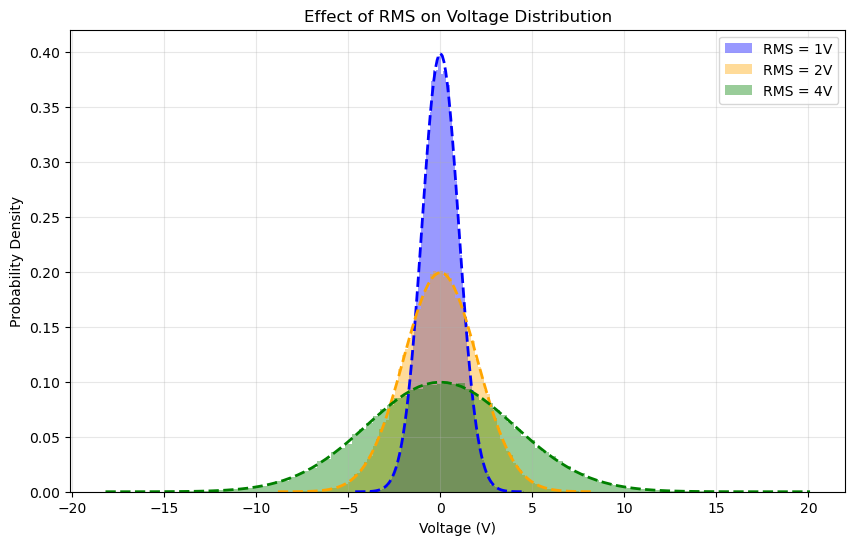

In [31]:
# histograms for different RMS values

# different RMS cases
rms_values = [1, 2, 4]
colors = ['blue', 'orange', 'green']
N = 100000

plt.figure(figsize=(10, 6))

for rms, color in zip(rms_values, colors):
    # signal
    voltage = np.random.normal(loc=0, scale=rms, size=N)
    
    # histogram (using 'step' or alpha for clear overlay)
    plt.hist(voltage, bins=100, density=True, alpha=0.4, color=color, label=f'RMS = {rms}V')
    
    x = np.linspace(min(voltage), max(voltage), 100)
    p = stats.norm.pdf(x, 0, rms)
    plt.plot(x, p, color=color, linewidth=2, linestyle='--')

plt.title('Effect of RMS on Voltage Distribution')
plt.xlabel('Voltage (V)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The voltage signal $V(t)$ is modeled as a zero-mean Gaussian random variable:
$$V \sim \mathcal{N}(0, \sigma^2)$$

The probability density function (PDF) is given by:
$$f_V(v) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{v^2}{2\sigma^2}}$$

Here, the **RMS value** corresponds to the standard deviation ($\sigma$):
$$V_{\text{RMS}} = \sqrt{E[V^2]} = \sigma$$

**Key Properties:**
* **Shape:** The histogram follows a "Bell Curve" centered at $v=0$.
* **Width:** The RMS value ($\sigma$) controls the width. A higher RMS means the signal spends more time at higher amplitudes, resulting in a broader, flatter distribution.
* **Area:** The total area under the curve is always 1.0. Therefore, as the RMS increases and the curve gets wider, the peak height must decrease.

# Q3 

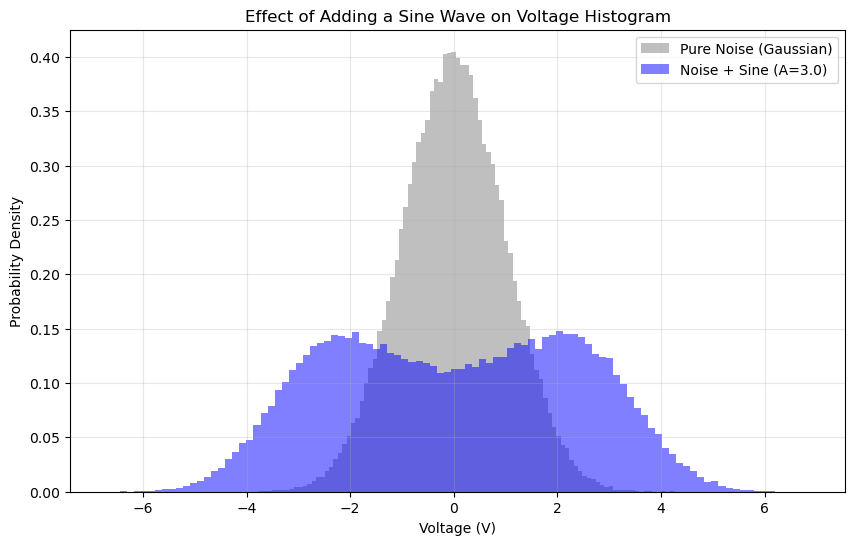

In [32]:

N = 100000
sigma_n = 1.0
noise = np.random.normal(0, sigma_n, N)

# sine wave parameters
A = 3.0  #amplitude ( A > sigma to clearly see the effect)
t = np.linspace(0, 100, N)
sine_wave = A * np.sin(t)

# combined Signal
signal_combined = noise + sine_wave

plt.figure(figsize=(10, 6))

# 1 pure noise histogram
plt.hist(noise, bins=100, density=True, alpha=0.5, color='gray', label='Pure Noise (Gaussian)')

# 2 combined signal histogram
plt.hist(signal_combined, bins=100, density=True, alpha=0.5, color='blue', label=f'Noise + Sine (A={A})')

plt.title('Effect of Adding a Sine Wave on Voltage Histogram')
plt.xlabel('Voltage (V)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We consider a **signal + noise** model where a deterministic sine wave is added to random Gaussian noise:
$$V_{\text{total}}(t) = V_{\text{noise}}(t) + A\sin(2\pi f_s t)$$

where $V_{\text{noise}} \sim \mathcal{N}(0, \sigma_n^2)$.

**Statistical Impact:**
1.  **Time-Varying Mean:** At any instant $t$, the local mean is shifted by $A\sin(2\pi f_s t)$.
2.  **Variance Increase:** Since the signal and noise are independent, the total variance is the sum of the variances:
    $$\text{Var}(V_{\text{total}}) = \sigma_n^2 + \frac{A^2}{2}$$
    The two terms are the **noise power** and the **signal power** — they add independently.
4.  **Shape Change (The "Bathtub" Effect):** A sine wave spends most of its time near its peaks ($\pm A$) and very little time crossing zero. Its probability density function (PDF) is U-shaped (Arcsine distribution).
    * When we add Gaussian noise, this U-shape is convolved with the Bell curve.
    * **If $A \gg \sigma_n$:** The distribution becomes **bimodal** (two distinct peaks near $\pm A$).
    * **If $A \ll \sigma_n$:** The noise dominates, and the distribution looks like a slightly wider Gaussian.

# Q4

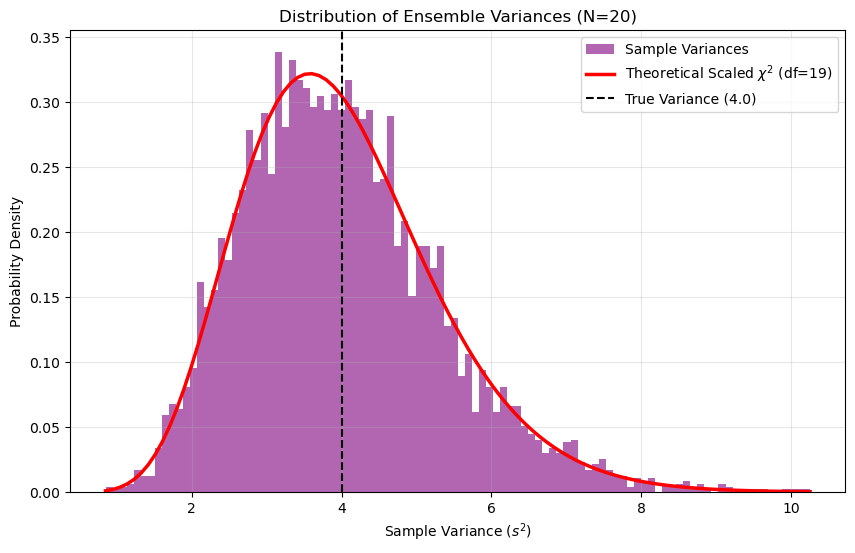

In [33]:
# distribution of ensemble variances

num_ensembles = 5000  # many experiments to get a smooth histogram
samples_per_ensemble = 20  # keeping N small to clearly see the Skewness/Asymmetry
true_sigma = 2.0
true_variance = true_sigma**2

# generating Ensembles (Matrix: rows=experiments, cols=samples)
# simulating 5000 experiments, each with 20 samples
ensembles = np.random.normal(0, true_sigma, (num_ensembles, samples_per_ensemble))

# calculating Sample Variance for each experiment (row-wise)
# ddof=1 is important for the unbiased estimator (dividing by N-1)
sample_variances = np.var(ensembles, axis=1, ddof=1)


plt.figure(figsize=(10, 6))

# 1 histogram of Sample Variances
count, bins, _ = plt.hist(sample_variances, bins=100, density=True, alpha=0.6, color='purple', label='Sample Variances')

# 2 theoretical PDF (Scaled Chi-Squared)
# variable Y = (N-1)s^2 / sigma^2 follows Chi-Squared(N-1)
# so s^2 follows a scaled Chi-Squared distribution.
df = samples_per_ensemble - 1  #degrees of freedom
x = np.linspace(min(bins), max(bins), 100)

# formula for scaled PDF:
y_theoretical = stats.chi2.pdf(x * df / true_variance, df) * (df / true_variance)

plt.plot(x, y_theoretical, 'r-', linewidth=2.5, label=f'Theoretical Scaled $\chi^2$ (df={df})')

plt.axvline(true_variance, color='k', linestyle='--', label=f'True Variance ({true_variance})')
plt.title(f'Distribution of Ensemble Variances (N={samples_per_ensemble})')
plt.xlabel('Sample Variance ($s^2$)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

For $N$ i.i.d. samples from $\mathcal{N}(0, \sigma^2)$, the sample variance:
$$s^2 = \frac{1}{N-1}\sum_{i=1}^{N}(V_i - \bar{V})^2$$

follows a scaled chi-squared distribution:
$$s^2 \sim \frac{\sigma^2}{N-1}\,\chi^2(N-1)$$

### Observations

**1. Shape of the Distribution**
The histogram of the ensemble variances (purple bars) does not follow a perfect Gaussian bell curve. Instead, it matches the theoretical Scaled Chi-Squared distribution(red curve).

**2. Asymmetry (Skewness)**
For the sample size used ($N=20$), the distribution is right-skewed (asymmetric).
* There is a longer "tail" to the right, meaning it is possible to occasionally estimate a variance much larger than the true value.
* The "mode" (peak) of the distribution is slightly to the left of the true variance.

**3. Unbiased Estimator**
Despite the skewness, the mathematical average (mean) of all these sample variances aligns with the vertical dashed line at the true variance ($\sigma^2 = 4$). This confirms that $s^2$ is an unbiased estimator of the population variance.